# Mean of Squared Successive Differences (MSSD)

------

*Author: Tien Le (Tyler Le)*

*Date: May 16, 2026*

*Last Updated: May 31, 2026*

*Version: 2.0:

In *[Jahng, 2008](<https://psycnet.apa.org/fulltext/2008-17368-004.pdf?auth_token=0e5b6390978f6f221e8a99d8533d5a6ab62a2e70>)*, MSSD **'has features of both variability and temporal dependency.'**


- MSSD measures variability between consecutive data points in a time series.

- Difference between MSE and MSSD is that MSSD measures variability in a time series.

- Helpful to measure degree of volatility in sequential observations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Linearly increase
x1 = np.linspace(start = 60, stop = 180, num = 600 )

# Alternates everyday
y1 = np.array([60, 180] * 300)

print(f"Mean x1: {x1.mean()}")
print(f"Mean y1: {y1.mean()}")

print(f"STD x1: {x1.std()}")
print(f"STD y1: {y1.std()}")


Mean x1: 120.0
Mean y1: 120.0
STD x1: 34.69879937110688
STD y1: 60.0


- Both records have the exact same mean.
- STD tells us that $y1$ is more spread out, but does not tell us about the instability of it



## Temporal dependency & variability



## Formula:

$$
MSSD = \dfrac{1}{n-1} \sum_{i=1}^{n-1} (x_{i+1} – x_i)^2
$$
$$
ST-MSSD = \dfrac{1}{N-J} \sum_{j=1}^{J}\sum_{i=1}^{n_j-1} (x_{(i+1)j} – x_{ij})^2
$$

$$
LT-MSSD = \dfrac{1}{J-1} \sum_{j=1}^{J-1} (\bar{x}_{j+1} – \bar{x}_j)^2
$$


$X_i$ = observation at time $i$

$n$ = total number of observations of a day

$J$ = total days of observation

Squared successive differences are averaged over $n-1$ pairs

## Interpretation

- **Base MSSD**: Flat sequence. Every pair gets the same treatment.
  - Averging overall for all observation, i, so it is NOT sustepible short-term + high frequency fluctations
  - Person's mood swing for an hour will not be visible in a week's observation.

- **Short Term MSSD**: Same day instatbility
  - Relies a reliable sampling rate every day

- **Long-term MSSD**: Day to day instability
  - Average each day, j, to a daily mean.
  - Doesn't capture details of a major mood swings within a given day.

Given a population SSD, $\lambda^2$, of a stationary time series as the expected value of the square successive difference, $E[(x_{i+1} - x_i)^2]$, it can expressed as a function of the population variance $\sigma^2$ & the population 1st-order autocorrelation p(1):

## For a stationary time series:


$\lambda^2 = E[(x_{i+1} - x_i)^2] = 2\sigma^2(1-p(1))$

# Pseudocode MSSD

We use Numpy

In [4]:
def mssd(observations: np.array) -> float:
  """
This makes MSSD a single index that jointly encodes both variability
    (sigma^2) and temporal dependency (rho)
  """

  # Get successive squared difference (x_{i+1} - x_i)^2
  sq_diff_arr = np.diff(observations) ** 2

  # SUM & divide by n-1
  mssd_arr = np.mean(sq_diff_arr) # / n-1

  return mssd_arr

import numpy as np

def st_mssd(observations: list[list[float]]) -> float:
    """
    Short-Term MSSD: average instability within days.
    """
    total_sq_diff = 0.0
    total_pairs = 0

    for day in observations:
        x = np.array(day, dtype = float)

        if len(x) < 2:
            continue

        sq_diffs = np.diff(x) ** 2
        total_sq_diff += sq_diffs.sum()
        total_pairs += len(sq_diffs)

    if total_pairs == 0:
        raise ValueError("Need at least one day with 2+ observations.")

    return total_sq_diff / total_pairs


def lt_mssd(observations: list[list[float]]) -> float:
    """
    Long-Term MSSD: instability between daily means.
    """

    daily_means = np.array([np.mean(day) for day in observations], dtype=float)

    if len(daily_means) < 2:
        raise ValueError("Need at least 2 days to compute LT-MSSD.")

    return (np.diff(daily_means) ** 2).sum() / (len(daily_means) - 1)

def theoretical_mssd(sigma2, rho) -> float:
    """
    Population MSSD

    delta^2 = 2 * sigma^2 * (1 - rho(1))

    Useful for verifying that sample MSSD converges to this as N grows.
    """
    return 2 * sigma2 * (1 - rho)

In [5]:
print("## Standard Metrics")
print(f"Mean x1: {x1.mean():.2f} | STD x1: {x1.std():.2f}")
print(f"Mean y1: {y1.mean():.2f} | STD y1: {y1.std():.2f}")


mssd_x1, mssd_y1 = mssd(x1), mssd(y1)
print("\n## Temporal Instability (MSSD)")
print(f"MSSD x1 (Linear)): {mssd_x1:.2f}")
print(f"MSSD y1 (Unstable shifts): {mssd_y1:.2f}")

## Standard Metrics
Mean x1: 120.00 | STD x1: 34.70
Mean y1: 120.00 | STD y1: 60.00

## Temporal Instability (MSSD)
MSSD x1 (Linear)): 0.04
MSSD y1 (Unstable shifts): 14400.00


A MSSD close to 0 tells us that there isn't a HUGE SHIFT in data, so x1 hasn't change that much.

A large MSSD that is really far away from 0 tells us that there is a temporal instability.  

# SYNTHETIC DATA

## Data:
https://www.kaggle.com/datasets/arashnic/fitbit/data

## Source: Fitbit Charge 6

- Heart Rate
- Sleep
- Steps

## Function
- MSSD
  - Per-user volatility

In [6]:
rng = np.random.default_rng(42)

def make_days(signal: np.ndarray, n_days: int, obs_per_day: int) -> list[list[float]]:
    """Chop a flat signal into day-sized chunks."""
    total = n_days * obs_per_day
    assert len(signal) >= total, "Signal too short for requested days/obs"
    return [signal[j * obs_per_day:(j + 1) * obs_per_day].tolist()
            for j in range(n_days)]

def ar1(n: int, rho: float, sigma: float, mu: float = 0.0) -> np.ndarray:
    """Stationary AR(1): x_t = mu + rho*(x_{t-1} - mu) + eps"""
    x = np.empty(n)
    x[0] = mu
    eps = rng.normal(0, sigma, n)
    for t in range(1, n):
        x[t] = mu + rho * (x[t - 1] - mu) + eps[t]
    return x

In [7]:
N_DAYS = 14
OBS    = 100   # obs per day

flat = make_days(np.full(N_DAYS * OBS, 70.0), N_DAYS, OBS)


linear_signal = np.repeat(np.linspace(60, 120, N_DAYS), OBS).astype(float) # Duplicate between n_days
linear_signal += rng.normal(0, 0.1, len(linear_signal))  # tiny within-day noise
linear = make_days(linear_signal, N_DAYS, OBS)

#    Each day alternates 60/120 bpm, but every day looks the same
chaos_day = np.tile([60.0, 120.0], OBS // 2)
chaotic = [chaos_day.tolist() for _ in range(N_DAYS)]

#    Each day is flat, but the flat level jumps between days
daily_means = [60, 90, 65, 95, 70, 100, 75]
stable_days = [
    (np.full(OBS, mu) + rng.normal(0, 0.5, OBS)).tolist()
    for mu in daily_means
]
# rho, sigma, top 10, 25% volatilty
# matplotlib


In [8]:
cases = {
    "Flat":            flat,         # all same values
    "Linear trend":    linear,       # gradually increase
    "Chaotic (60/120)":chaotic,      # up & downs each day
    "Stable+shifting": stable_days,  # Flat within-day but jumps between days
}

print(f"{'Case':<22} {'ST-MSSD':>10} {'LT-MSSD':>10}")
print("-" * 44)
for name, data in cases.items():
    st = st_mssd(data)
    lt = lt_mssd(data)
    print(f"{name:<22} {st:>10.3f} {lt:>10.3f}")


Case                      ST-MSSD    LT-MSSD
--------------------------------------------
Flat                        0.000      0.000
Linear trend                0.018     21.304
Chaotic (60/120)         3600.000      0.000
Stable+shifting             0.528    758.413


In [9]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download("arashnic/fitbit")

print("Path to dataset files:", path)

100%|██████████| 43.3M/43.3M [00:01<00:00, 37.3MB/s]

Extracting files...


Path to dataset files: /Users/tienle/.cache/kagglehub/datasets/arashnic/fitbit/versions/2


In [10]:
import pandas as pd

# Set the path to the file you'd like to load
file_path = f"{path}/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv"

# Load the dataset using pandas
df = pd.read_csv(file_path)

df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


# Synthetic Generator

## Scope
- 100 users
- 14 days
- 5 EMA responses / day
- Mock HR
- Add volatility

## Modules

1. MSSD methods (pandas)
   - Base
   - Short-term
   - Long-term

2. Generator

3. Threshold
  - Top-k %

4. Visualization (matplotlib)



*EMA: Ecological Momentary Assessment.*

In [11]:
def mssd(observations: np.array) -> float:
  """
  Mean Square of Successive Differences (von Neumann; Jahng et al. 2008).

        MSSD = (1 / k) * sum_i (x_{i+1} - x_i)^2

    where the sum runs over the k pairs of temporally adjacent, both-observed
    points. Missing values (NaN) are NOT bridged: any pair touching a NaN is
    dropped, and the denominator k is the number of valid pairs, not n - 1.

    Parameters
    ----------
    observations : array-like, shape (n,)
        Ordered, equally spaced values for ONE user and ONE signal.
        Use NaN for missing observations.

    Returns
    -------
    float
        MSSD, or np.nan if there are fewer than two valid adjacent pairs.
  """
  obs = np.asarray(observations, dtype=(float))

  if obs.shape[0] < 2:
    raise ValueError(f"Expected more observations to perform MSSD, got {observations.shape[0]} entries")
  if obs.ndim != 1:
        raise ValueError(f"expected 1D input, got shape {obs.shape}")

  # Get successive squared difference (x_{i+1} - x_i)^2
  sq_diff_arr = np.diff(obs) ** 2

  # Get count of valid data outdside of  NaN
  valid = np.count_nonzero(~np.isnan(sq_diff_arr))
  if valid == 0:
      return np.nan
  # SUM & divide by n-1
  mssd_arr = np.nansum(sq_diff_arr) / valid

  return mssd_arr

In [12]:
obs = [3, 4, np.nan, 2, 5, np.nan]

print("Difference: " , np.diff(obs))

obs_sq = np.diff(obs)**2
print("Squared: " , obs_sq)

valid_pairs = np.count_nonzero(~np.isnan(np.diff(obs)))
print("Count valid pairs: " , valid_pairs)

mssd_obs = np.nansum(np.diff(obs)**2) / valid_pairs
print("Example MSSD: ", mssd_obs)
print("Expected MSSD: ", mssd(obs))




Difference:  [ 1. nan nan  3. nan]
Squared:  [ 1. nan nan  9. nan]
Count valid pairs:  2
Example MSSD:  5.0
Expected MSSD:  5.0


# Synthetic Data

## EMA
- Questions when users are prompted to respond to

Note: response rate to Ecological Momentary Assessment (EMA) often are dependent from the previous mood or psychological state. True randomness in missing responses does not provide us the representation of a high stake environment like a sporting, or major event.
The expectationo missing responses should be considered as it is within reasonable grounds that nautral participants will not always respond our app's survey X times a day.

## Health Data
- Heart Rate

## Out-of-scope
- Steps
- Sleep




---
# Known Volatility



$\mu$ = User baseline (mean of the population)

$\sigma$ = User Volatility (std)

$\rho$ = User lag-1 autocorrelation [-1, 1]. Degree of dependency of the current state to the previous state.

Given a population, some are calm/predictable, but some are volatile/swingy

For testing, we need to keep our samples fixed and reproducible aka ground truth.

---

## First-Order Autoregressive Model

*['Autoregressions', Economics-With-R](<https://www.econometrics-with-r.org/14.3-autoregressions.html>)*

An autoregressive model relates a time series variable to its past values.

In our case, the goal is to 'model' a person's fluctuating psychological state, which is **dependent on the previous state**.

Formula:

$$
z_t = \rho * z_{t-1} + e_t
$$

$z_t$: User's state

$z_{t-1}$: User's state at the previous time step

$e_t$ : Random noise that influence user's state (e.g. FSU just scored, just took some cognac, hitting a PR)

e_t ~ $Normal(0, \sigma_{e^2})$ : random noise is Normally distributed.
  - On average, most noise are close to the mean, 0, but sometimes, depending $\sigma_{e^2}$, it can be influential

---

In [13]:

def generate_user(user_id,
                  days,
                  ema_per_day,
                  rng,
                  resp_rate=0.80,
                  mean_gap_length = 3):
    """

    Generate one user's EMA series with KNOWN latent volatility.
    Assumes sample is normally distributed


    """

    n = days * ema_per_day

    # per-user latent parameters (ground truth for the population)
    mu    = rng.uniform(2.0, 4.0)
    sigma = rng.uniform(0.3, 1.5) # How volatile a person is (0 means they are exactly at the mean)
    rho   = rng.uniform(0.1, 0.8) # personal correlation

    # AR(1)  -- consecutive points are related
    # lambda^2 = E[(x_{i+1} - x_i)^2] = 2\sigma^2(1-p(1))


    z = np.zeros(n)
    z[0] = rng.normal(0, sigma) # define mean, and std (degree of spread)
    for t in range(1, n):
      z[t] = rho * z[t-1] + rng.normal(0, sigma * np.sqrt(1 - rho**2))
    latent = mu + z

    # map latent to Likert response
    ema = np.clip(np.round(latent), 1, 5)


    mask = _clustered_missing_mask(n, resp_rate, mean_gap_length, rng) # bool mask
    ema[mask] = np.nan

    expected_mssd = 2.0 * sigma**2 * (1 - rho) # ground truth

    return pd.DataFrame({
        "user_id": user_id,
        "prompt_idx": np.arange(n),
        "day": np.arange(n) // ema_per_day,
        "ema": ema,
        "true_sigma": sigma,
        "true_rho": rho,
        "true_expected_mssd": expected_mssd,
    })


def _clustered_missing_mask(n, resp_rate, mean_gap_length, rng):
    """
    Boolean mask of length n where True = missing (NaN), generated by a
    two-state Markov chain so that missingness arrives in clusters.

    resp_rate        : fraction of prompts answered (missing rate m = 1 - resp_rate)
    mean_gap_length  : average length of a missing run, in prompts (>= 1)
    rng              : np.random.Generator

    The long-run missing rate is m regardless of clustering; mean_gap_length
    only controls how the misses are clumped.
    """

    missing_rate = 1.0 - resp_rate

    if missing_rate <= 0.0:
      return np.zeros(n, dtype=bool) # nobody miss answering

    elif missing_rate >= 1.0:
      return np.ones(n, dtype=bool) # everything misses

    if mean_gap_length < 1.0:
      raise ValueError("mean_gap_length must be >= 1")

    # trannsition probabilities
    b = 1.0 / mean_gap_length # P(missing -> responding): ending a gap
    a = missing_rate * b / (1.0 - missing_rate) # P(responding -> missing) [0,1] starts a gap

    # feasiability
    if a > 1.0:
        raise ValueError(
            f"infeasible combo: mean_gap_length {mean_gap_length:.2f} with mean gap "
            f"{mean_gap_length} needs P(start gap) = {a:.2f} > 1. "
            f"lower the missing rate or allow longer gaps."
        )
    mask = np.zeros(n, dtype=bool)
    missing = rng.random() < missing_rate
    mask[0] = missing
    for t in range(1, n):
      if missing:
        missing = rng.random() >= b # stay missing

      else:
        missing = rng.random() < a # start a gap w/ P(responding -> missing)

      mask[t] = missing

    return mask

def generate_cohort(users = 100,
                    days  = 14,
                    ema_per_day = 5,
                    seed = 0,
                    resp_rate = 0.8,
                    mean_gap_length = 3):

    if users < 1:
      raise ValueError(f"Need more than one user to generate... got {users}")
    if days < 1:
      raise ValueError(f"Need more than one day to generate... got {days}")
    if ema_per_day < 1:
      raise ValueError(f"Need more than one day to generate... got {ema_per_day}")
    if resp_rate > 1 or resp_rate < 0:
      raise ValueError(f"Need RESPONSE RATE within range [0,1]... got {resp_rate}")


    rng = np.random.default_rng(seed)
    return pd.concat(
        [generate_user(uid, days, ema_per_day, rng, resp_rate, mean_gap_length) for uid in range(users)],
        ignore_index=True,
    )


In [14]:
df = generate_cohort(users = 100,
                    days  = 14,
                    ema_per_day = 5,
                    seed = 0,
                    resp_rate = 0.8,
                    mean_gap_length = 3)

df.head()

,user_id,prompt_idx,day,ema,true_sigma,true_rho,true_expected_mssd
0,0,0,0,3.0,0.623744,0.128681,0.677985
1,0,1,0,3.0,0.623744,0.128681,0.677985
2,0,2,0,3.0,0.623744,0.128681,0.677985
3,0,3,0,4.0,0.623744,0.128681,0.677985
4,0,4,0,4.0,0.623744,0.128681,0.677985


In [15]:
pd.value_counts(df['ema'].isna()) # ratio = resp_rate

/var/folders/6y/w83434vd58jf6rqmf82sh3yc0000gn/T/ipykernel_8817/2982186761.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['ema'].isna()) # ratio = resp_rate


ema
False    5529
True     1471
Name: count, dtype: int64

In [16]:
computed_mssd = df.groupby("user_id")["ema"].apply(mssd).rename("computed_mssd")
expected_mssd = df.groupby("user_id")["true_expected_mssd"].first()

check = pd.concat([computed_mssd, expected_mssd], axis=1)
print(check.corr(method = "spearman"))


                    computed_mssd  true_expected_mssd
computed_mssd            1.000000            0.927797
true_expected_mssd       0.927797            1.000000


# Visualization:
1. Gap length historogram
2. Per-user missing rate histoogram
3. response raster, sticky and scatter_matrix
4. Knob sweep (small multiples of gaps)
5. Single user time series

In [17]:
# HELPERS
def _run_lengths(mask):
    """Lengths of consecutive True (missing) runs in a 1D boolean array."""
    runs, current = [], 0
    for v in mask:
        if v:
            current += 1
        elif current:
            runs.append(current); current = 0
    if current:
        runs.append(current)
    return runs

def missing_matrix(df):
    """users x prompts boolean matrix, True = missing, from a cohort df."""
    wide = df.pivot(index="user_id", columns="prompt_idx", values="ema")
    return wide.isna().to_numpy()

# gap-length histogram
def plot_gap_histogram(df, mean_gap_length, ax=None):

    gaps = [g for row in missing_matrix(df) for g in _run_lengths(row)]
    if not gaps:
        print("no gaps to plot")
        return
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    maxlen = max(gaps)
    ax.hist(gaps,
            bins = np.arange(0.5, maxlen + 1.5, 1),
            density = True,
            alpha = 0.7,
            edgecolor = "white",
            label = "observed")

    # P(end gap)
    b = 1.0 / mean_gap_length
    k = np.arange(1, maxlen + 1)
    ax.plot(k, (1 - b) ** (k - 1) * b, "o-", color="crimson",
            label=f"geometric, mean {mean_gap_length}")
    ax.axvline(np.mean(gaps), color="black", ls="--",
               label=f"observed mean {np.mean(gaps):.4f}")

    ax.set_xlabel("gap length (consecutive missed prompts)")
    ax.set_ylabel("density"); ax.set_title("Missing-run length distribution")
    ax.legend()

# Per-user missing rate
def plot_missing_rate_histogram(df, resp_rate, ax=None):

    # Helper
    def find_avg_missing(obs: np.array):
      return obs.isna().mean()

    # For each EMA, find average missing responses
    rates = df.groupby("user_id")["ema"].apply(find_avg_missing)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    ax.hist(rates, bins=20, alpha=0.7, edgecolor="white")
    ax.axvline(1.0 - resp_rate, color="crimson", ls="--",
               label=f"target {1.0 - resp_rate:.2f}")
    ax.axvline(rates.mean(), color="black", ls=":",
               label=f"cohort mean {rates.mean():.3f}")

    ax.set_xlabel("fraction of prompts missing (per user)")
    ax.set_ylabel("number of users"); ax.set_title("Per-user missing rate")
    ax.legend()

# Response rate: sticky vs. scatter
# how correlated are non-responses?

def plot_response_raster(df, resp_rate, seed=1, n_show=40):

    """
    Compare response randomness to clustered responses

    """
    sticky = missing_matrix(df)
    n_show = min(n_show, sticky.shape[0])
    n_prompts = sticky.shape[1]
    missing_rate = 1.0 - resp_rate

    # MCAR baseline: each prompt independently missing, no memory
    rng = np.random.default_rng(seed)
    scatter = rng.random((n_show, n_prompts)) < missing_rate

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, mat, title in [(axes[0], sticky[:n_show], "Sticky (Current Clustered)"),
                           (axes[1], scatter,         "Scatter (MCAR baseline)")]:
        ax.imshow(mat, aspect="auto", cmap="binary", interpolation="nearest")
        ax.set_title(f"{title}\nrealized missing {mat.mean():.2f}")
        ax.set_xlabel("prompt (time)")
    axes[0].set_ylabel("user")
    fig.suptitle("Response raster, black = missing")
    fig.tight_layout()



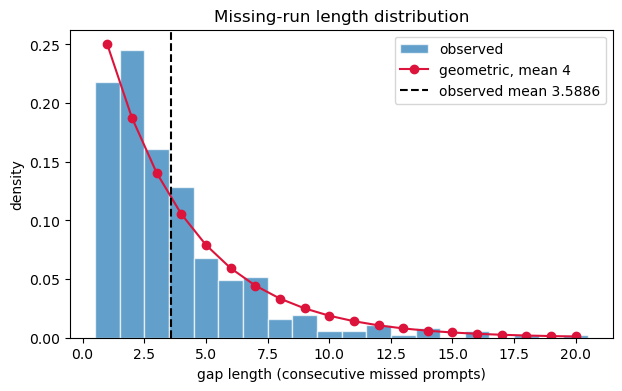

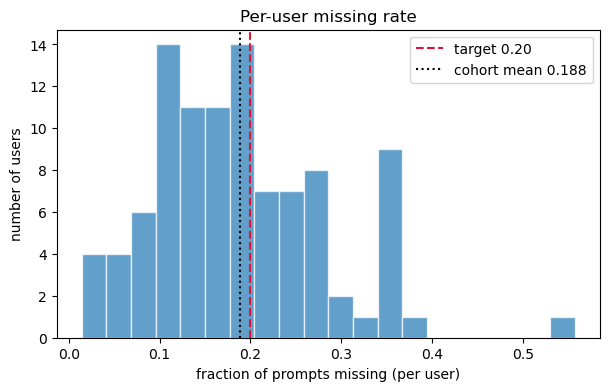

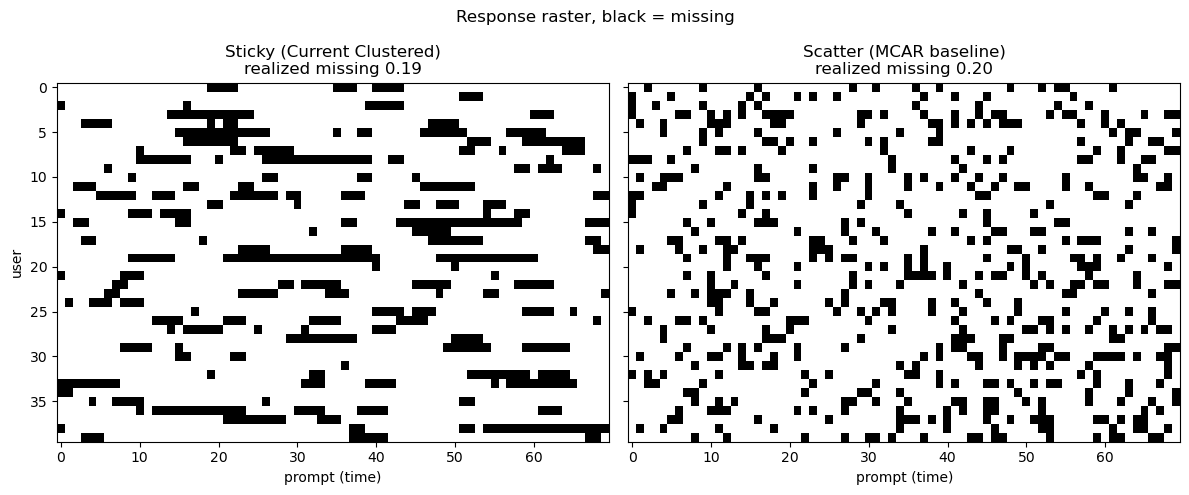

In [18]:
RESP_RATE, MEAN_GAP = 0.80, 4
df = generate_cohort(users  = 100,
                     days   = 14,
                     ema_per_day = 5,
                     seed = 0,
                     resp_rate = RESP_RATE,
                     mean_gap_length = MEAN_GAP)

plot_gap_histogram(df, MEAN_GAP)
plt.show()

plot_missing_rate_histogram(df, RESP_RATE)
plt.show()

plot_response_raster(df, RESP_RATE)
plt.show()

